In [95]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, skew, kurtosis
import datetime as dt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor, XGBClassifier
from sklearn.svm import SVC, SVR
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.base import TransformerMixin, BaseEstimator, clone, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

In [96]:
data = pd.read_csv("train.csv")
#test = pd.read_csv("test.csv")
store = pd.read_csv("store.csv")

In [97]:
data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [98]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


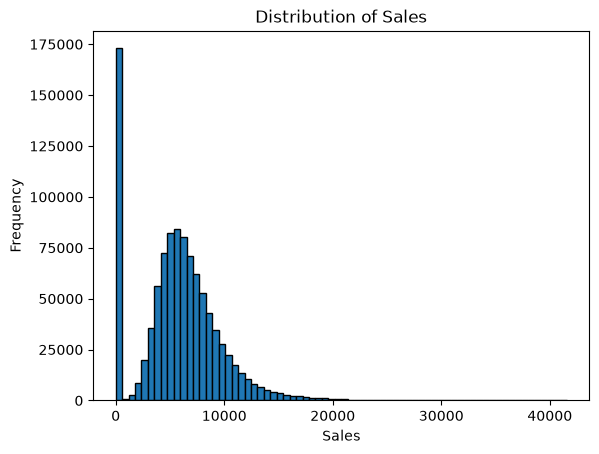

In [99]:
plt.hist(data['Sales'], bins=70, edgecolor='black')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

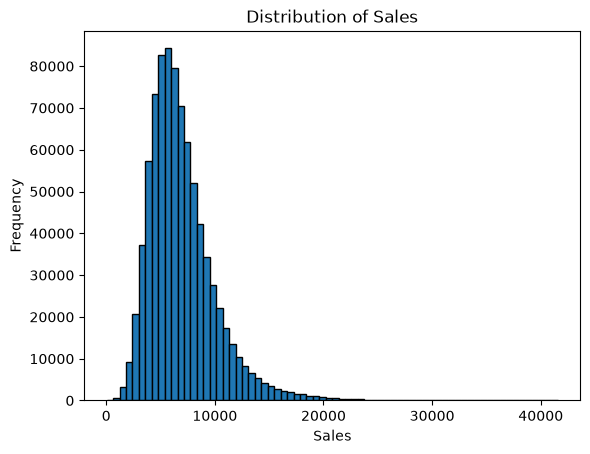

In [100]:
plt.hist(data[data['Sales']>0]['Sales'], bins=70, edgecolor='black')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

In [101]:
new_df = (
    data.groupby('Store', as_index=False)[['Sales', 'Customers']]
      .sum()
      .rename(columns={'Customers': 'Customer'})
)

new_df['SalesperCustomer'] = new_df['Sales']/new_df['Customer']
new_df.drop(columns=['Sales', 'Customer'], inplace=True)

store = pd.merge(store, new_df, on='Store')
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,SalesperCustomer
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,8.437366
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",8.482725
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",9.255808
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,7.292138
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,8.702634


In [102]:
store['havePI'] = store['PromoInterval'].notna().astype(int)
store['haveP2SY'] = store['Promo2SinceYear'].notna().astype(int)
store['haveP2SW'] = store['Promo2SinceWeek'].notna().astype(int)
store['haveCOSY'] = store['CompetitionOpenSinceYear'].notna().astype(int)
store['haveCOSM'] = store['CompetitionOpenSinceMonth'].notna().astype(int)
store['haveCD'] = store['CompetitionDistance'].notna().astype(int)

In [103]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,SalesperCustomer,havePI,haveP2SY,haveP2SW,haveCOSY,haveCOSM,haveCD
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,8.437366,0,0,0,1,1,1
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",8.482725,1,1,1,1,1,1
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",9.255808,1,1,1,1,1,1
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,7.292138,0,0,0,1,1,1
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,8.702634,0,0,0,1,1,1


In [104]:
store['PromoInterval'].value_counts().sort_values(ascending=False)

PromoInterval
Jan,Apr,Jul,Oct     335
Feb,May,Aug,Nov     130
Mar,Jun,Sept,Dec    106
Name: count, dtype: int64

In [105]:
store.shape

(1115, 17)

In [106]:
missing = store.isnull().sum()
miss_cols = missing[missing>0]
print(miss_cols)

CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [107]:
missing = data.isnull().sum()
miss_cols = missing[missing>0]
print(miss_cols)

Series([], dtype: int64)


In [108]:
impute = SimpleImputer(strategy='constant', fill_value=0)
store = pd.DataFrame(impute.fit_transform(store), columns=store.columns, index=store.index)
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,SalesperCustomer,havePI,haveP2SY,haveP2SW,haveCOSY,haveCOSM,haveCD
0,1,c,a,1270.0,9.0,2008.0,0,0,0,0,8.437366,0,0,0,1,1,1
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",8.482725,1,1,1,1,1,1
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",9.255808,1,1,1,1,1,1
3,4,c,c,620.0,9.0,2009.0,0,0,0,0,7.292138,0,0,0,1,1,1
4,5,a,a,29910.0,4.0,2015.0,0,0,0,0,8.702634,0,0,0,1,1,1


In [109]:
data = data[data['Sales'] > 0]

In [110]:
import datetime as dt

In [111]:
data['Date'] = pd.to_datetime(data['Date'])
data['is_weekend'] = (data['DayOfWeek']>6).astype(int)
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day
data['year'] = data['Date'].dt.year
data['weekofyear'] = data['Date'].dt.isocalendar().week.astype(int)
data.drop(columns=['Date'], inplace=True)

In [116]:
train = pd.merge(data, store, on='Store')
y_train = train['Sales']
train.drop(columns=['Sales', 'Customers'], inplace=True)
train.head()

,Store,DayOfWeek,Open,Promo,StateHoliday,SchoolHoliday,is_weekend,month,day,year,...,Promo2SinceWeek,Promo2SinceYear,PromoInterval,SalesperCustomer,havePI,haveP2SY,haveP2SW,haveCOSY,haveCOSM,haveCD
0,1,5,1,1,0,1,0,7,31,2015,...,0,0,0,8.437366,0,0,0,1,1,1
1,2,5,1,1,0,1,0,7,31,2015,...,13.0,2010.0,"Jan,Apr,Jul,Oct",8.482725,1,1,1,1,1,1
2,3,5,1,1,0,1,0,7,31,2015,...,14.0,2011.0,"Jan,Apr,Jul,Oct",9.255808,1,1,1,1,1,1
3,4,5,1,1,0,1,0,7,31,2015,...,0,0,0,7.292138,0,0,0,1,1,1
4,5,5,1,1,0,1,0,7,31,2015,...,0,0,0,8.702634,0,0,0,1,1,1


In [117]:
print(train.columns)

Index(['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday',
       'is_weekend', 'month', 'day', 'year', 'weekofyear', 'StoreType',
       'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'SalesperCustomer', 'havePI',
       'haveP2SY', 'haveP2SW', 'haveCOSY', 'haveCOSM', 'haveCD'],
      dtype='str')


In [119]:
cat_cols = ['StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
train[cat_cols] = train[cat_cols].astype(str)
ohe = OneHotEncoder()
col = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder = 'passthrough',verbose_feature_names_out=False,)

cated_array = col.fit_transform(train)

train = pd.DataFrame(
    cated_array,
    columns=col.get_feature_names_out(),
    index=train.index,
)

print(train.shape)

(844338, 38)


In [132]:
regressor=LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=0.1,
        feature_fraction=0.5,
        bagging_fraction=0.8,
        bagging_freq=1,
        n_jobs=1,
    )

In [121]:
import numpy as np
from sklearn.metrics import make_scorer

def rmspe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0                      # avoid division by zero
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))


rmspe_scorer = make_scorer(rmspe, greater_is_better=False)

In [ ]:
for col in train.select_dtypes(include='object').columns:
    print(col, train[col].unique()[:10])

In [ ]:
for feat in train.select_dtypes(include='object').columns:
    print(f"{feat}: {train[feat].dtype}")
    train[feat] = train[feat].astype(float)

In [123]:
for feat in train.select_dtypes(include='object').columns:
    print(f"{feat}: {train[feat].dtype}")

In [125]:
train.columns = (
    train.columns
     .astype(str)
     .str.replace(r'[,\[\]{}":]', '_', regex=True)
)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(
    regressor, train, y_train,
    cv=5,
    scoring=rmspe_scorer,
    n_jobs=-1
)

# scores are negative → flip sign back
rmspe_scores = -scores
print("RMSPE per fold:", rmspe_scores)
print("Mean RMSPE:", rmspe_scores.mean())

RMSPE per fold: [0.27074759 0.361268   0.2569278  0.28046641 0.38371324]
Mean RMSPE: 0.31062460706190625
